In [1]:
###########################################################################################################################################################

In [ ]:
#Python demo for 3.2 (SLP vs MLP)

SLP_LogReg: Train Acc=0.845, Test Acc=0.904
MLP_Shallow_(8): Train Acc=0.852, Test Acc=0.900
MLP_Deep_(32,32): Train Acc=0.935, Test Acc=0.964

Summary Results:
               model  train_accuracy  test_accuracy
0        SLP_LogReg        0.845333          0.904
1   MLP_Shallow_(8)        0.852000          0.900
2  MLP_Deep_(32,32)        0.934667          0.964


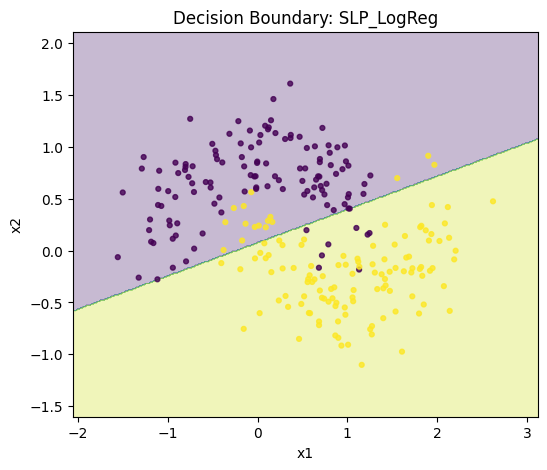

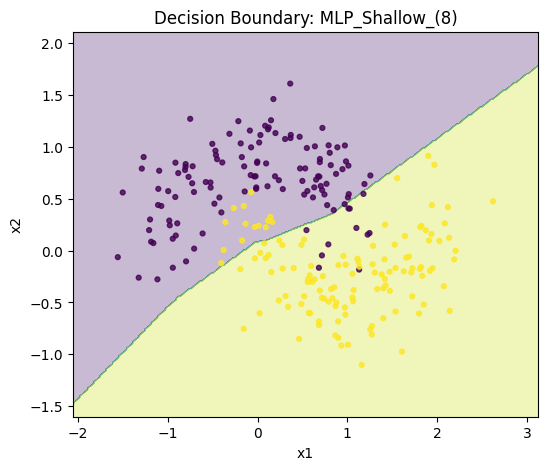

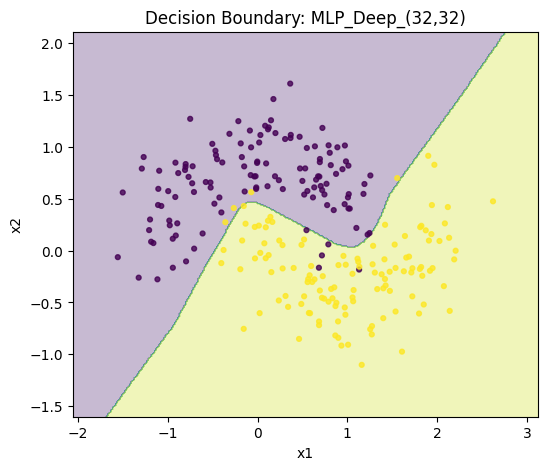

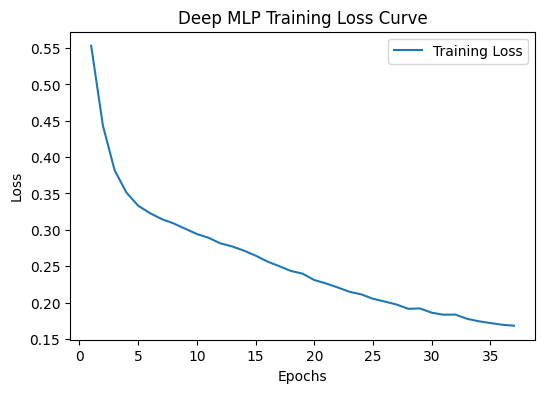

In [3]:
# Week 3.2 Demo: Single Layer Perceptron vs Multi-Layer Perceptron
# ---------------------------------------------------------------
# Compares Logistic Regression (SLP) vs shallow MLP vs deep MLP
# on a non-linear "moons" dataset.
#
# You get:
#   - Train/Test accuracy
#   - Decision boundary plots
#   - Training curve for deep MLP
#
# Requirements: pip install numpy matplotlib scikit-learn pandas

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 1) Generate dataset -------------------------------------------------------
X, y = make_moons(n_samples=1000, noise=0.25, random_state=RANDOM_STATE)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

# 2) Define models ----------------------------------------------------------
slp = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=200, random_state=RANDOM_STATE))
])
#mlp_shallow / mlp_deep → scikit-learn pipeline with MLPClassifier (classical ML-style neural nets)
mlp_shallow = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(8,),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        batch_size=32,
        learning_rate_init=1e-3,
        max_iter=300,
        early_stopping=True,
        random_state=RANDOM_STATE
    ))
])

mlp_deep = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(32, 32),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        batch_size=32,
        learning_rate_init=1e-3,
        max_iter=400,
        early_stopping=True,
        random_state=RANDOM_STATE
    ))
])

models = {
    "SLP_LogReg": slp,
    "MLP_Shallow_(8)": mlp_shallow,
    "MLP_Deep_(32,32)": mlp_deep
}

# 3) Train & evaluate -------------------------------------------------------
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_tr_pred = model.predict(X_train)
    y_te_pred = model.predict(X_test)
    tr_acc = accuracy_score(y_train, y_tr_pred)
    te_acc = accuracy_score(y_test, y_te_pred)
    results.append({
        "model": name,
        "train_accuracy": tr_acc,
        "test_accuracy": te_acc
    })
    print(f"{name}: Train Acc={tr_acc:.3f}, Test Acc={te_acc:.3f}")

# Convert to DataFrame
df_results = pd.DataFrame(results)
print("\nSummary Results:\n", df_results)

# 4) Plot decision boundaries -----------------------------------------------
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=12, alpha=0.8)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

for name, model in models.items():
    plot_decision_boundary(model, X_test, y_test, f"Decision Boundary: {name}")

# 5) Learning curve for deep MLP --------------------------------------------
deep_clf = mlp_deep.named_steps["clf"]
train_loss = getattr(deep_clf, "loss_curve_", None)

if train_loss is not None:
    plt.figure(figsize=(6, 4))
    plt.plot(range(1, len(train_loss)+1), train_loss, label="Training Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Deep MLP Training Loss Curve")
    plt.legend()
    plt.show()


In [ ]:
# add more layers

2025-09-03 07:01:41.647822: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-03 07:01:41.654640: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756882901.662561 3502411 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756882901.665102 3502411 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1756882901.672772 3502411 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897 (3.50 KB)

 Trainable params: 897 (3.50 KB)

...

Epoch 1/50


I0000 00:00:1756882903.757243 2860841 service.cc:152] XLA service 0x7571b400be70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1756882903.757257 2860841 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2025-09-03 07:01:43.769479: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1756882903.852868 2860841 cuda_dnn.cc:529] Loaded cuDNN version 90501


 1/19 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.5625 - loss: 0.6732

I0000 00:00:1756882904.276800 2860841 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.7478 - loss: 0.5544 - val_accuracy: 0.8733 - val_loss: 0.3320
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8511 - loss: 0.3334 - val_accuracy: 0.8667 - val_loss: 0.3018
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8886 - loss: 0.2824 - val_accuracy: 0.9067 - val_loss: 0.2440
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9379 - loss: 0.1716 - val_accuracy: 0.9200 - val_loss: 0.1981
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9282 - loss: 0.1646 - val_accuracy: 0.9133 - val_loss: 0.1851
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9317 - loss: 0.1687 - val_accuracy: 0.9000 - val_loss: 0.1972
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9324 - loss: 0.1692 - val_accuracy: 0.9067 - val_loss: 0.2103
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9408 - loss: 0.1419 - val_accuracy: 0.9200 - val_loss: 0.2068
Ep

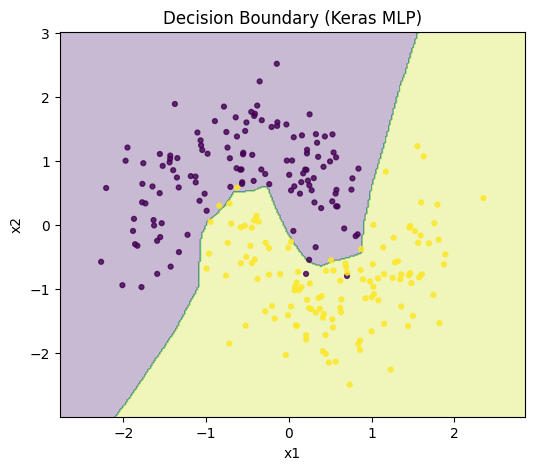

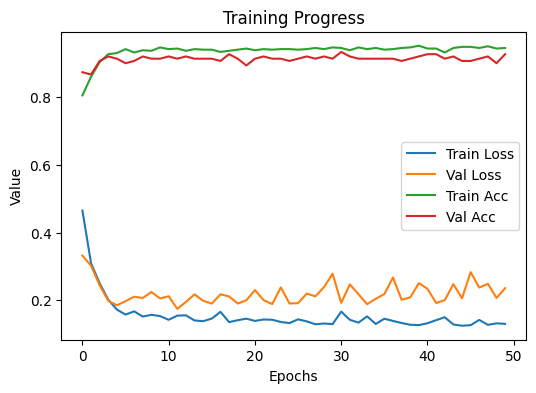

In [2]:
# Week 3.2 Demo with TensorFlow/Keras
# Feedforward Neural Network (MLP) on make_moons classification task
#
# You can easily add/remove layers in the `build_model()` function.
#
# Requirements:
#   pip install tensorflow scikit-learn matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers

# 1) Generate dataset -------------------------------------------------------
RANDOM_STATE = 42
X, y = make_moons(n_samples=1000, noise=0.25, random_state=RANDOM_STATE)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 2) Build model ------------------------------------------------------------
#build_model() → Keras Sequential API (deep learning)
def build_model():
    model = keras.Sequential([
        layers.Input(shape=(2,)),          # input layer (2 features: x1, x2)
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(32, activation="relu"),  # uncomment to add another layer
        
        # --- Output layer ---
        layers.Dense(1, activation="sigmoid")   # binary classification
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.01),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_model()
model.summary()

# 3) Train model ------------------------------------------------------------
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

# 4) Evaluate ---------------------------------------------------------------
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.3f}")

# 5) Plot decision boundary -------------------------------------------------
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = model.predict(grid, verbose=0)
    Z = (preds > 0.5).astype(int).reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=12, alpha=0.8)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

plot_decision_boundary(model, X_test, y_test, "Decision Boundary (Keras MLP)")

# 6) Plot learning curves ---------------------------------------------------
plt.figure(figsize=(6, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.xlabel("Epochs")
plt.ylabel("Value")
plt.title("Training Progress")
plt.legend()
plt.show()


In [ ]:
# how this model is trained? and how to select the best parameter value that minimize your loss and improve your accurcy? :) next Video

In [ ]:
###########################################################################################################################################################

In [ ]:
###########################################################################################################################################################

In [6]:
##########Week 3.5 Demo: Backpropagation & Optimizers (TensorFlow/Keras)


Training with SGD...

Training with Adam...


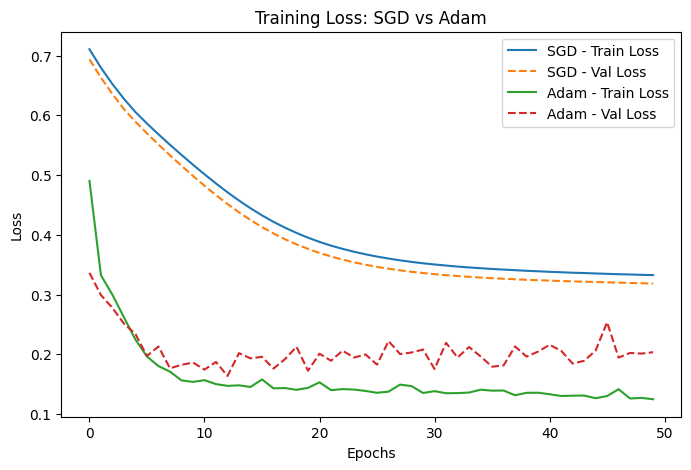

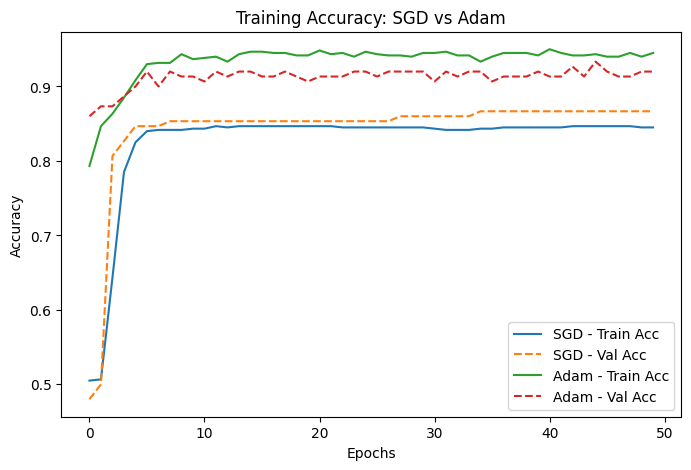

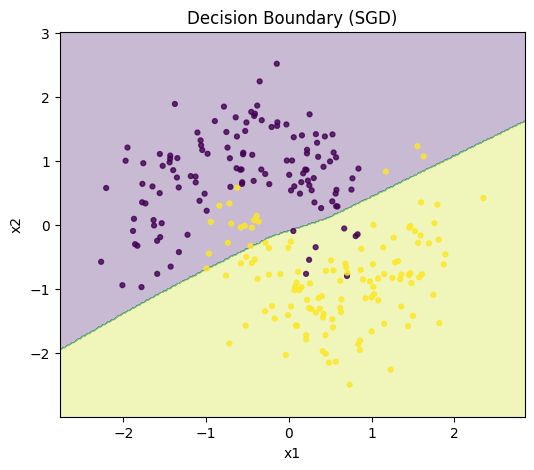

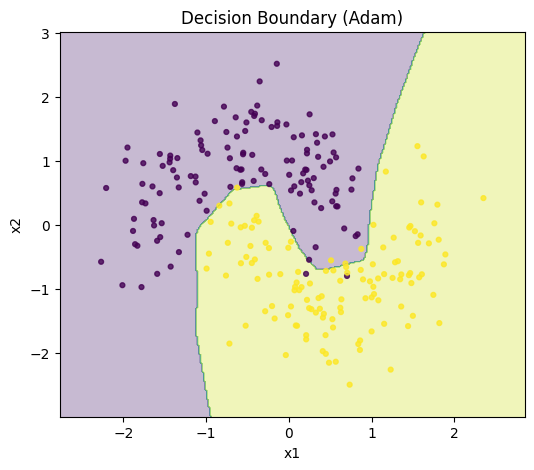

In [7]:
# Week 3.4 Demo: Backpropagation & Optimizers
# -------------------------------------------
# Train a feedforward neural network (MLP) on make_moons dataset
# Compare SGD vs Adam optimizers and visualize how they update weights
#
# Requirements:
#   pip install tensorflow scikit-learn matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers

# 1) Generate dataset --------------------------------------------------------
RANDOM_STATE = 42
X, y = make_moons(n_samples=1000, noise=0.25, random_state=RANDOM_STATE)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 2) Build model function ----------------------------------------------------
def build_model(optimizer):
    model = keras.Sequential([
        layers.Input(shape=(2,)),
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

# 3) Train with SGD vs Adam --------------------------------------------------
optimizers = {
    "SGD": keras.optimizers.SGD(learning_rate=0.01, momentum=0.0),
    "Adam": keras.optimizers.Adam(learning_rate=0.01)
}

histories = {}
models = {}

for opt_name, opt in optimizers.items():
    print(f"\nTraining with {opt_name}...")
    model = build_model(opt)
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=32,
        verbose=0
    )
    models[opt_name] = model
    histories[opt_name] = history

# 4) Plot training curves ----------------------------------------------------
plt.figure(figsize=(8, 5))
for opt_name, history in histories.items():
    plt.plot(history.history["loss"], label=f"{opt_name} - Train Loss")
    plt.plot(history.history["val_loss"], label=f"{opt_name} - Val Loss", linestyle="--")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss: SGD vs Adam")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
for opt_name, history in histories.items():
    plt.plot(history.history["accuracy"], label=f"{opt_name} - Train Acc")
    plt.plot(history.history["val_accuracy"], label=f"{opt_name} - Val Acc", linestyle="--")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy: SGD vs Adam")
plt.legend()
plt.show()

# 5) Decision boundary plots -------------------------------------------------
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = model.predict(grid, verbose=0)
    Z = (preds > 0.5).astype(int).reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=12, alpha=0.8)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

for name, model in models.items():
    plot_decision_boundary(model, X_test, y_test, f"Decision Boundary ({name})")


In [ ]:
###########################################################################################################################################################

In [ ]:
###########################################################################################################################################################

In [8]:
# Demo Python 3.7 - Grid Search

In [8]:
#pip install tensorflow scikeras scikit-learn matplotlib numpy pandas

In [ ]:
## Runs GridSearchCV over hidden sizes, activation, solver, lr, batch, L2

Fitting 5 folds for each of 240 candidates, totalling 1200 fits

Best CV Accuracy: 0.9373
Best Params:
  mlp__activation: relu
  mlp__alpha: 0.0001
  mlp__batch_size: 64
  mlp__hidden_layer_sizes: (64, 32)
  mlp__learning_rate_init: 0.005
  mlp__solver: adam

Generalization (Test) Accuracy: 0.9800

Top 10 Configurations:
 mean_test_score  std_test_score  mean_train_score  std_train_score param_mlp__hidden_layer_sizes param_mlp__activation param_mlp__solver  param_mlp__learning_rate_init  param_mlp__batch_size  param_mlp__alpha  rank_test_score
        0.937333        0.035926          0.940000         0.008367                      (64, 32)                  relu              adam                          0.005                     64            0.0010                1
        0.937333        0.035926          0.939333         0.008731                      (64, 32)                  relu              adam                          0.005                     64            0.0001              

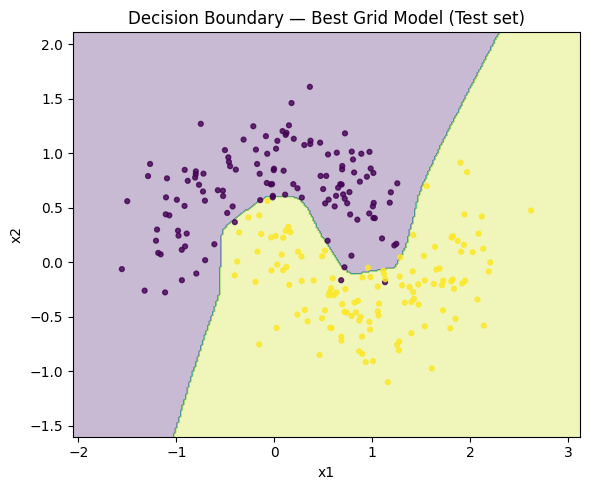

In [10]:
# Week 3.6 Demo — Grid Search for MLP (Classification on make_moons)
# ---------------------------------------------------------------
# What this script does:
# 1) Generates make_moons data
# 2) Builds a Pipeline: StandardScaler -> MLPClassifier
# 3) Runs GridSearchCV over hidden sizes, activation, solver, lr, batch, L2
# 4) Prints best params/scores + shows a compact results table
#
# Run:
#   pip install scikit-learn matplotlib numpy pandas
#   python week3_6_gridsearch_mlp.py

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="lbfgs failed to converge")  # just in case

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier

# -----------------------
# 1) Data
# -----------------------
RANDOM_STATE = 42
X, y = make_moons(n_samples=1000, noise=0.25, random_state=RANDOM_STATE)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

# -----------------------
# 2) Pipeline & Grid
# -----------------------
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        max_iter=400,            # keep modest; early_stopping helps
        early_stopping=True,
        n_iter_no_change=15,
        validation_fraction=0.15,
        random_state=RANDOM_STATE
    ))
])

param_grid = {
    # model capacity
    "mlp__hidden_layer_sizes": [ #mlp__hidden_layer_sizes: 5 options → [(8,), (16,), (32,), (32,16), (64,32)]
        (8,), (16,), (32,),       #1 hidden layer with 8 neurons
        (32, 16), (64, 32)        #2 hidden layers: first has 32 neurons, second has 16
    ],
    "mlp__activation": ["relu", "tanh"],
    # optimization
    "mlp__solver": ["adam", "sgd"],
    "mlp__learning_rate_init": [1e-2, 5e-3, 1e-3],
    "mlp__batch_size": [32, 64],
    # regularization
    "mlp__alpha": [1e-4, 1e-3],
}

#mlp__hidden_layer_sizes: 5 options → [(8,), (16,), (32,), (32,16), (64,32)]

#mlp__activation: 2 options → ["relu", "tanh"]

#mlp__solver: 2 options → ["adam", "sgd"]

#mlp__learning_rate_init: 3 options → [0.01, 0.005, 0.001]

#mlp__batch_size: 2 options → [32, 64]

#mlp__alpha: 2 options → [1e-4, 1e-3]

#Total combinations = 5×2×2×3×2×2=240
#40×5=1200 model fits during CV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# -----------------------
# 3) Fit grid search
# -----------------------
grid.fit(X_train, y_train)

# -----------------------
# 4) Results
# -----------------------
print("\nBest CV Accuracy: {:.4f}".format(grid.best_score_))
print("Best Params:")
for k, v in grid.best_params_.items():
    print(f"  {k}: {v}")

best_model = grid.best_estimator_
test_acc = best_model.score(X_test, y_test)
print("\nGeneralization (Test) Accuracy: {:.4f}".format(test_acc))

# Build a tidy DataFrame
results = pd.DataFrame(grid.cv_results_)
cols_to_show = [
    "mean_test_score", "std_test_score",
    "mean_train_score", "std_train_score",
    "param_mlp__hidden_layer_sizes", "param_mlp__activation",
    "param_mlp__solver", "param_mlp__learning_rate_init",
    "param_mlp__batch_size", "param_mlp__alpha",
    "rank_test_score"
]

results = results[cols_to_show].sort_values("rank_test_score")
print("\nTop 10 Configurations:")
print(results.head(10).to_string(index=False))

# Optional: save CSV
results.to_csv("week3_6_gridsearch_results.csv", index=False)
print("\nSaved full grid results to: week3_6_gridsearch_results.csv")

# -----------------------
# 5) OPTIONAL heatmap visualization
#    (fix activation & solver to best, then show a 2D heatmap over
#     hidden_layer_sizes vs learning_rate_init by mean_test_score)
# -----------------------
try:
    best_act = grid.best_params_["mlp.activation"]
    best_sol = grid.best_params_["mlp.solver"]
    subset = results[
        (results["param_mlp.activation"] == best_act) &
        (results["param_mlp.solver"] == best_sol)
    ][["param_mlp.hidden_layer_sizes", "param_mlp.learning_rate_init", "mean_test_score"]]

    # pivot for heatmap
    pivot = subset.pivot_table(
        index="param_mlp.hidden_layer_sizes",
        columns="param_mlp.learning_rate_init",
        values="mean_test_score",
        aggfunc="mean"
    )

    plt.figure(figsize=(6, 4))
    plt.imshow(pivot, aspect="auto")
    plt.xticks(range(len(pivot.columns)), [str(c) for c in pivot.columns], rotation=45)
    plt.yticks(range(len(pivot.index)), [str(i) for i in pivot.index])
    plt.colorbar(label="CV Accuracy")
    plt.title(f"CV Accuracy Heatmap ({best_act}, {best_sol})")
    plt.xlabel("learning_rate_init")
    plt.ylabel("hidden_layer_sizes")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("\n[Heatmap skipped] Reason:", str(e))

# -----------------------
# 6) Train final best model on full train & visualize boundary
# -----------------------
def plot_decision_boundary(clf, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=12, alpha=0.8)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.tight_layout()
    plt.show()

# Refit best model on the entire training set (GridSearchCV already refits by default)
plot_decision_boundary(best_model, X_test, y_test, "Decision Boundary — Best Grid Model (Test set)")
#regularization strength

In [ ]:
###########################################################################################################################################################

In [ ]:
###########################################################################################################################################################

In [ ]:
# Demo 3.9: Neural Network for Classification

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,185 (4.63 KB)

 Trainable params: 1,185 (4.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.7865 - loss: 0.4915 - val_accuracy: 0.8667 - val_loss: 0.3227
Epoch 2/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8219 - loss: 0.3600 - val_accuracy: 0.8667 - val_loss: 0.2959
Epoch 3/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8541 - loss: 0.2905 - val_accuracy: 0.8600 - val_loss: 0.2792
Epoch 4/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8628 - loss: 0.2848 - val_accuracy: 0.8800 - val_loss: 0.2426
Epoch 5/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9164 - loss: 0.2216 - val_accuracy: 0.9200 - val_loss: 0.2003
Epoch 6/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9371 - loss: 0.1735 - val_accuracy: 0.9200 - val_loss: 0.2042
Epoch 7/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9432 - loss: 0.1556 - val_accuracy: 0.9133 - val_loss: 0.1865
Epoch 8/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9476 - loss: 0.1547 - val_accuracy: 0.9000 - 

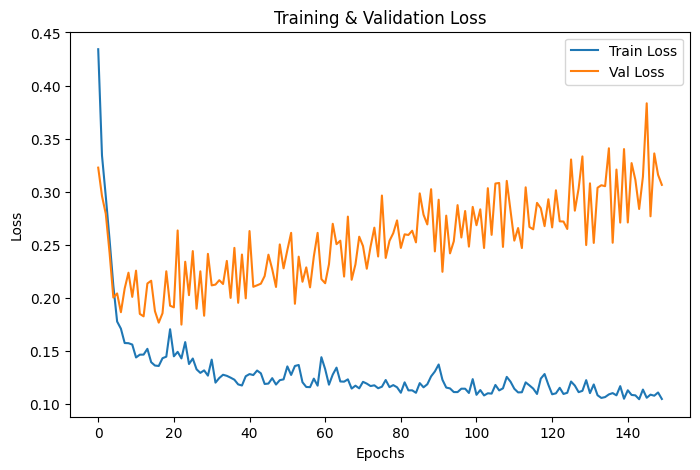

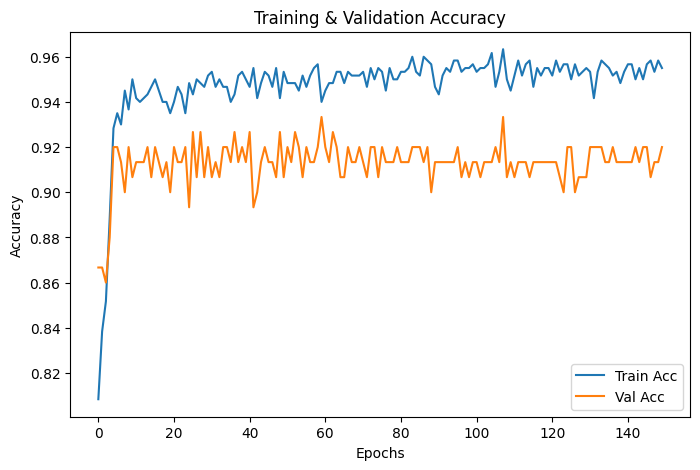

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


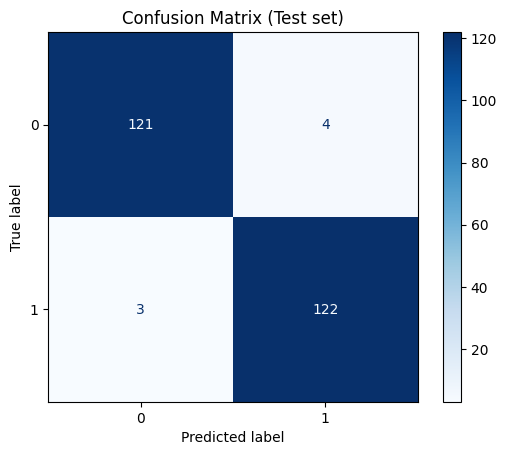

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


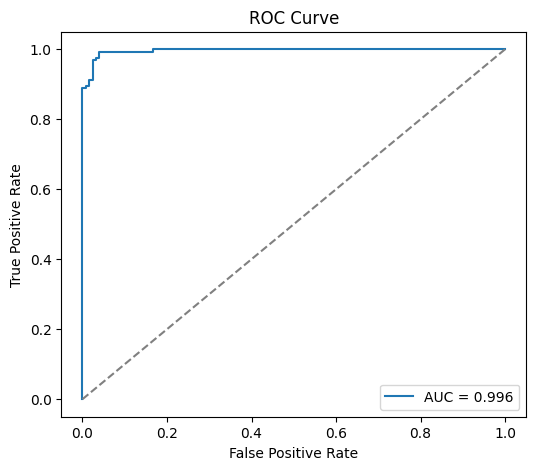

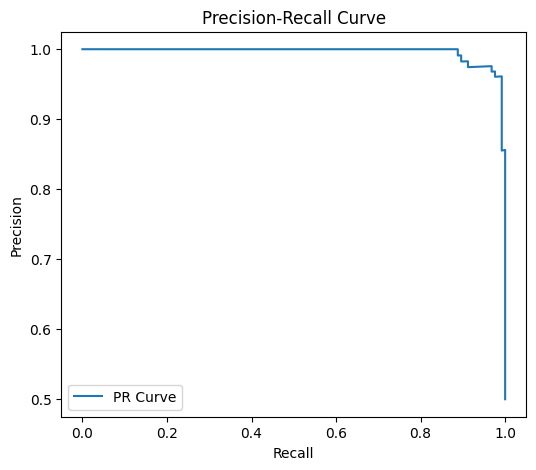

In [5]:
# Week 3.9 Demo: Neural Network for Classification
# ------------------------------------------------
# Dataset: make_moons
# Model: MLP in TensorFlow/Keras
# Outputs:
#   - Train/Validation loss & accuracy curves
#   - Test accuracy
#   - Confusion matrix
#   - ROC curve + AUC
#   - Precision-Recall curve
#
# Run: pip install tensorflow scikit-learn matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from tensorflow import keras
from tensorflow.keras import layers

# 1) Dataset -----------------------------------------------------------------
RANDOM_STATE = 42
X, y = make_moons(n_samples=1000, noise=0.25, random_state=RANDOM_STATE)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 2) Build model -------------------------------------------------------------
def build_model():
    model = keras.Sequential([
        layers.Input(shape=(2,)),
        layers.Dense(32, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid")   # binary classification
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.01),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_model()
model.summary()

# 3) Train -------------------------------------------------------------------
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=32,
    verbose=1
)

# 4) Evaluate ----------------------------------------------------------------
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.3f}")

# 5) Plot training curves ----------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()
plt.show()

# 6) Confusion matrix --------------------------------------------------------
y_pred = (model.predict(X_test) > 0.5).astype("int32")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Test set)")
plt.show()

# 7) ROC curve & AUC ---------------------------------------------------------
y_prob = model.predict(X_test).ravel()
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# 8) Precision-Recall curve --------------------------------------------------
prec, rec, _ = precision_recall_curve(y_test, y_prob)
plt.figure(figsize=(6, 5))
plt.plot(rec, prec, label="PR Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()
